# Lecture 4 — Cross-Validation

We first implement the Lecture 4 workflow ourselves using the Lecture 3 linear SVM optimizer. Only after understanding the mechanism do we use scikit-learn.

For fixed alpha: $\theta^*(\alpha)=\arg\min_{\theta}J(\theta;\alpha)$.

For hyperparameter selection: $\alpha^*=\arg\max_{\alpha}S(\alpha)$.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

for candidate in [Path.cwd(), Path.cwd() / 'unit_0/lecture_4']:
    if (candidate / 'cross_validation_from_scratch.py').exists():
        sys.path.insert(0, str(candidate))
        break

from cross_validation_from_scratch import fit_linear_svm, cross_validate_alpha, accuracy

## 1. Reuse Lecture 3

Our objective is $J(\theta;\alpha)=\text{average hinge loss}+\alpha\,\frac{1}{2}\|\theta\|^2$. The optimizer is the same gradient-descent idea from Lecture 3. The new idea is how we choose alpha.

epoch=   0 | J=1.000000 | accuracy=0.538 | theta=[0.00923077 0.01538462] | theta0=0.0008
epoch= 100 | J=0.624112 | accuracy=0.538 | theta=[0.06895054 0.22806913] | theta0=-0.2054
epoch= 200 | J=0.565011 | accuracy=0.615 | theta=[0.08659177 0.27400179] | theta0=-0.4431
epoch= 300 | J=0.506339 | accuracy=0.692 | theta=[0.10118815 0.31847341] | theta0=-0.6808
epoch= 400 | J=0.447928 | accuracy=0.846 | theta=[0.11273221 0.36149119] | theta0=-0.9185
epoch= 500 | J=0.389650 | accuracy=0.923 | theta=[0.12893122 0.40458901] | theta0=-1.1554
epoch= 600 | J=0.331759 | accuracy=0.923 | theta=[0.14283682 0.45009951] | theta0=-1.3915
epoch= 700 | J=0.274472 | accuracy=0.923 | theta=[0.16138057 0.49570581] | theta0=-1.6269
epoch= 800 | J=0.235776 | accuracy=1.000 | theta=[0.17455265 0.53157937] | theta0=-1.8162
epoch= 900 | J=0.209911 | accuracy=1.000 | theta=[0.18937048 0.55659763] | theta0=-1.9723
epoch= 999 | J=0.192927 | accuracy=1.000 | theta=[0.20499526 0.57925552] | theta0=-2.0992
training ac

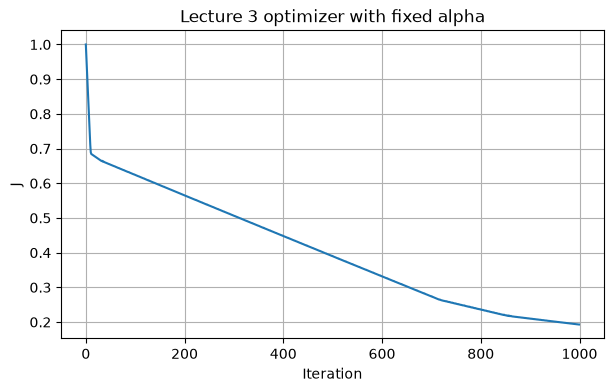

In [2]:
X = np.array([[4,4],[5,3],[3,5],[1,1],[2,1],[1,2],[4,1],[2,5],[2,2],[1,5],[1,3],[3,4],[5,4]], dtype=float)
y = np.array([1,1,1,-1,-1,-1,-1,1,-1,1,-1,1,1], dtype=float)

theta, theta0, history = fit_linear_svm(X, y, alpha=0.05, epochs=1000, verbose=True)
print('training accuracy:', accuracy(X, y, theta, theta0))

plt.figure(figsize=(7,4))
plt.plot(history['objective'])
plt.xlabel('Iteration')
plt.ylabel('J')
plt.title('Lecture 3 optimizer with fixed alpha')
plt.grid(True)
plt.show()

## 2. K-fold cross-validation from scratch

For each candidate alpha we train a fresh model on 4 folds and validate on the fifth, rotating the validation fold. Then we average the five validation accuracies.

alpha=0.0001 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.00014874 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.00022122 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.00032903 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.00048939 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0007279 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0010826 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0016103 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.002395 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0035622 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0052983 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.0078805 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.011721 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.017433 | folds=[1.    0.667 1.    1.    1.   ] | mean=0.933
alpha=0.025929 | folds=[1.    0.667 

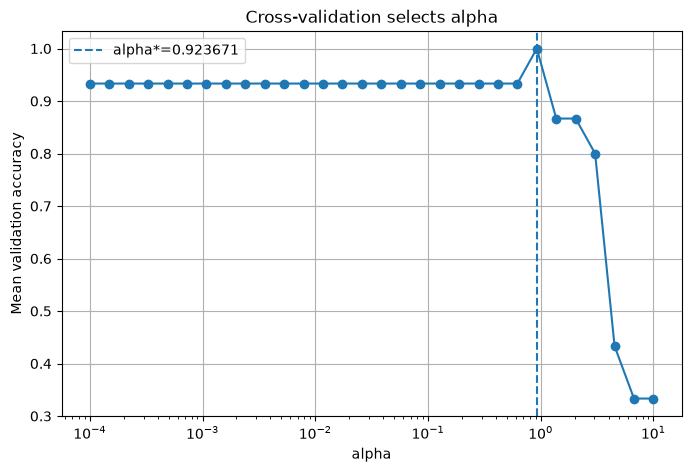

In [7]:
alphas = np.logspace(-4, 1, 30)
results, alpha_star = cross_validate_alpha(X, y, alphas, k=5, seed=42, epochs=1000)
scores = np.array([r['mean_validation_accuracy'] for r in results])
print('alpha* =', alpha_star)

plt.figure(figsize=(8,5))
plt.semilogx(alphas, scores, marker='o')
plt.axvline(alpha_star, linestyle='--', label=f'alpha*={alpha_star:g}')
plt.xlabel('alpha')
plt.ylabel('Mean validation accuracy')
plt.title('Cross-validation selects alpha')
plt.grid(True)
plt.legend()
plt.show()

## 3. Retrain with alpha*

After model selection, retrain on all available training examples using alpha*. The final test set should remain untouched until this point.

In [4]:
theta_star, theta0_star, final_history = fit_linear_svm(X, y, alpha_star, epochs=1000)
print('Selected alpha*:', alpha_star)
print('theta*:', theta_star)
print('theta0*:', theta0_star)
print('Final training accuracy:', accuracy(X, y, theta_star, theta0_star))

Selected alpha*: 0.0001
theta*: [0.21371473 0.58267572]
theta0*: -2.1261538461538625
Final training accuracy: 1.0


## 4. Now use scikit-learn

Only now do we use an external library. It packages the same ideas: hinge loss, L2 regularization, optimization, fold splitting, and validation scoring.

scikit-learn alpha* = 0.021544346900318846
best CV accuracy = 0.9771774569166277


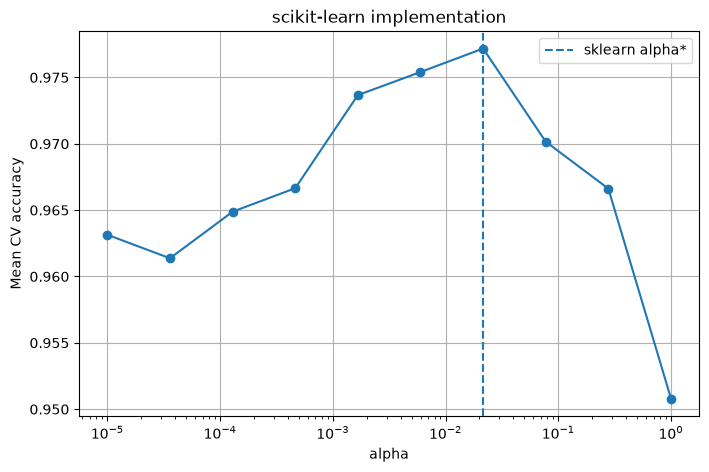

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

data = load_breast_cancer()
X_cancer, y_cancer = data.data, data.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sk_alphas = np.logspace(-5, 0, 10)
sk_scores = []

for alpha in sk_alphas:
    model = make_pipeline(StandardScaler(), SGDClassifier(loss='hinge', penalty='l2', alpha=alpha, max_iter=2000, tol=1e-4, random_state=42))
    sk_scores.append(cross_val_score(model, X_cancer, y_cancer, cv=cv, scoring='accuracy').mean())

sk_alpha_star = float(sk_alphas[np.argmax(sk_scores)])
print('scikit-learn alpha* =', sk_alpha_star)
print('best CV accuracy =', max(sk_scores))

plt.figure(figsize=(8,5))
plt.semilogx(sk_alphas, sk_scores, marker='o')
plt.axvline(sk_alpha_star, linestyle='--', label='sklearn alpha*')
plt.xlabel('alpha')
plt.ylabel('Mean CV accuracy')
plt.title('scikit-learn implementation')
plt.grid(True)
plt.legend()
plt.show()